# Gap Matching — Roster Need Scorer

Computes how well a player's individual stat profile fills the specific statistical gaps in a school's current roster, position by position.

**Feature space:**

| Layer | Dims | Player source | Position weight source |
|---|---|---|---|
| Stat profile | 8 | `player_season_stats` (ppg, rpg, apg, spg, bpg, ts%, usage%, 3pt rate) | — |
| Position weights | 5 (soft) | `hoop_explorer_player_stats.pos_confidence_*` (59.3% coverage) | one-hot `players.position` fallback (40.7%) |

`gap_match` in DB = soft-weighted cosine similarity between a player's scaled stat vector and a school's position-specific gap vector (`max(0, league_benchmark - roster_mean)`), summed across positions using the player's position-confidence weights.

**Output:** `player_team_fit_scores.gap_match` — same player×school×season pairs already scored by Model 3 (no new pairs added).

**Prerequisites:**
- `scheme_fit_scorer.ipynb` complete → `player_team_fit_scores` populated (defines pair scope)
- `player_clustering.ipynb` complete → `player_archetypes` populated (archetype deficit flag)
- `player_season_stats` + `hoop_explorer_player_stats` populated in DB

**Known limitations (see Cell 0 for detail):**
- `transfers` table is empty — no departure filter; roster = everyone in `player_season_stats` for that school/season
- `player_school_seasons` is empty — roster source is `player_season_stats.school_id`
- `breakdown.gap.uniqueness_bonus` / `redundancy_penalty` not yet computed — API placeholders until a v2 adds them

In [1]:
# Cell 0 — Imports + Config
import os, json, warnings
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import psycopg2
from psycopg2.extras import execute_values
from dotenv import load_dotenv

from portalpoint.modeling import gap_matching as gm
from portalpoint.modeling.io import find_repo_root, get_sync_engine

warnings.filterwarnings('ignore')
load_dotenv()

# ── paths ────────────────────────────────────────────────────────────────────
ROOT       = find_repo_root()
MODELS_DIR = ROOT / 'data' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── config — pulled from src/portalpoint/modeling/gap_matching.py ────────────
SEASONS_IN_DATA = [2021, 2022, 2023, 2024, 2025, 2026]
CURRENT_SEASON  = max(SEASONS_IN_DATA)

GAP_FEATURES = gm.GAP_FEATURES
POS_COLS  = gm.POS_COLS
POS_NAMES = gm.POS_NAMES
POS_IDX   = {p: i for i, p in enumerate(POS_NAMES)}

MIN_GAMES     = gm.MIN_GAMES
MODEL_VERSION = gm.MODEL_VERSION
W_GAP, W_SCHEME, W_ROLE, W_PROG = gm.W_GAP, gm.W_SCHEME, gm.W_ROLE, gm.W_PROG

# ── KNOWN LIMITATIONS ───────────────────────────────────────────
# gap-cos-v2 (2026-06-21, Issue #26): transfers table now has real rows (season
#   2026, 1,251) — departure filter applied below (Cell 1b), current season only.
#   Scoped to confirmed portal transfers; graduations/draft departures still count
#   as roster-resident (roster_state_features.open_minutes_by_position covers that
#   broader case separately, not wired in here).
# player_school_seasons: 0 rows — roster source is player_season_stats.school_id.

print('Config loaded — seasons:', SEASONS_IN_DATA)


Config loaded — seasons: [2021, 2022, 2023, 2024, 2025, 2026]


## 1. Load Player Stats

Pulls 8-dim stat vectors from `player_season_stats`, joined to `players.position` and LEFT JOINed to `hoop_explorer_player_stats` for soft position confidence. Filters to `games_played >= MIN_GAMES` and all 8 features non-null. Deduplicated to one row per `(player_id, season)` — mid-season transfers keep the row with more games played.

In [2]:
# Cell 1 — DB connect + load player stats with soft position weights
# Joins player_season_stats + players + LEFT JOIN hoop_explorer_player_stats.
# HE coverage: ~59% of rows. Remaining 41% get one-hot fallback in Cell 2.
engine = get_sync_engine()
conn   = engine.raw_connection()

LOAD_SQL = f"""
SELECT
    pss.player_id,
    pss.school_id,
    pss.season,
    pss.games_played,
    p.position,
    pss.points_per_game,
    pss.rebounds_per_game,
    pss.assists_per_game,
    pss.steals_per_game,
    pss.blocks_per_game,
    pss.true_shooting_pct,
    pss.usage_rate,
    pss.three_point_rate,
    hep.pos_confidence_pg,
    hep.pos_confidence_sg,
    hep.pos_confidence_sf,
    hep.pos_confidence_pf,
    hep.pos_confidence_c
FROM player_season_stats pss
JOIN players p ON p.id = pss.player_id
LEFT JOIN hoop_explorer_player_stats hep
    ON hep.player_id = pss.player_id AND hep.season = pss.season
WHERE pss.games_played           >= {MIN_GAMES}
  AND pss.points_per_game        IS NOT NULL
  AND pss.rebounds_per_game      IS NOT NULL
  AND pss.assists_per_game       IS NOT NULL
  AND pss.steals_per_game        IS NOT NULL
  AND pss.blocks_per_game        IS NOT NULL
  AND pss.true_shooting_pct      IS NOT NULL
  AND pss.usage_rate             IS NOT NULL
  AND pss.three_point_rate       IS NOT NULL
"""

with conn.cursor() as cur:
    cur.execute(LOAD_SQL)
    cols = [d[0] for d in cur.description]
    df   = pd.DataFrame(cur.fetchall(), columns=cols)

# Dedup: keep row with most games_played per (player_id, season)
df = (
    df.sort_values('games_played', ascending=False)
      .drop_duplicates(subset=['player_id', 'season'], keep='first')
      .reset_index(drop=True)
)

he_cov = df[POS_COLS].notna().all(axis=1).sum()
print(f'Loaded {len(df):,} player-season rows')
print(f'HE pos_confidence coverage: {he_cov:,}/{len(df):,} ({100*he_cov/len(df):.1f}%)')
print('\nRows per season:')
print(df['season'].value_counts().sort_index())


Loaded 26,865 player-season rows
HE pos_confidence coverage: 16,043/26,865 (59.7%)

Rows per season:
season
2021    4239
2022    4504
2023    4521
2024    4532
2025    4541
2026    4528
Name: count, dtype: int64


## 1b. Load Departures (gap-cos-v2)

Excludes players who transferred out of a school (per `transfers`) from that school's own roster pool, **current season only** — historical seasons' rosters are already correct as-is. Scoped to confirmed portal transfers (`transfers.from_school_id`/`to_school_id`); graduations/draft departures aren't tracked here (see `roster_state_features.open_minutes_by_position` for that broader case). Mirrors `scripts/run_gap_matching.py` exactly via `gm.filter_departed()`.

In [3]:
# Cell 1b — Load departures + filter (gap-cos-v2)
# Exact query from docs/models/gap_matching_plan.md Cell 2 / run_gap_matching.py's DEPARTED_SQL.
DEPARTED_SQL = """
SELECT player_id, from_school_id
FROM transfers
WHERE from_school_id IS NOT NULL
  AND portal_entry_date IS NOT NULL
  AND season = %s
"""

with conn.cursor() as cur:
    cur.execute(DEPARTED_SQL, (CURRENT_SEASON,))
    departed_pairs = {(r[0], r[1]) for r in cur.fetchall()}

print(f'Departed pairs loaded for season {CURRENT_SEASON}: {len(departed_pairs):,}')

df = gm.filter_departed(df, departed_pairs, CURRENT_SEASON)
print(f'Rows after departure filter: {len(df):,}')


Departed pairs loaded for season 2026: 1,251


Rows after departure filter: 25,618


## 2. Soft Position Assignment

HE `pos_confidence_pg/sg/sf/pf/c` already sums to ~1.0 and is used directly where available (~59% of rows). The remaining ~41% (no HE match) fall back to a one-hot vector from `players.position`. Both paths are renormalized to guard against rounding drift or rows with no position data at all.

In [4]:
# Cell 2 — Soft position weights
# For ~41% of rows without HE data, fall back to one-hot from players.position.
# pos_confidence already sums to ~1.0 for HE rows (validated in DB audit).
mask_no_he = df[POS_COLS].isna().all(axis=1)
print(f'Rows using one-hot fallback (no HE match): {mask_no_he.sum():,}')
print(f'Position breakdown of fallback rows:')
print(df[mask_no_he]['position'].value_counts())

df = gm.assign_soft_positions(df)

# Flag zero-sum rows (player with no position data at all)
zero_weight = (df[POS_COLS].sum(axis=1) < 0.01).sum()
if zero_weight > 0:
    print(f'WARNING: {zero_weight} rows with zero position weights — will score as 0')

print('\npos_confidence sum stats after normalization:')
print(df[POS_COLS].sum(axis=1).describe().round(4))


Rows using one-hot fallback (no HE match): 10,424
Position breakdown of fallback rows:
position
G    10424
Name: count, dtype: int64

pos_confidence sum stats after normalization:
count    25618.0000
mean         0.5931
std          0.4913
min          0.0000
25%          0.0000
50%          1.0000
75%          1.0000
max          1.0000
dtype: float64


## 3. League Benchmarks

For each season and position, computes the soft-weighted mean stat vector across all players — i.e. "what does an average PG/SG/SF/PF/C look like this season." This is the target every school's roster is compared against per position.

In [5]:
# Cell 3 — League benchmarks per season × position (soft-weighted)
benchmarks = gm.build_league_benchmarks(df, SEASONS_IN_DATA)

bench_df = pd.DataFrame(
    benchmarks[CURRENT_SEASON],
    index=POS_NAMES,
    columns=GAP_FEATURES,
).round(2)
print(f'League benchmark ({CURRENT_SEASON}) — weighted mean stats per position:')
print(bench_df.to_string())


League benchmark (2026) — weighted mean stats per position:
    points_per_game  rebounds_per_game  assists_per_game  steals_per_game  blocks_per_game  true_shooting_pct  usage_rate  three_point_rate
PG             9.52               2.71              2.17             0.54             0.14              52.57       20.41              0.44
SG             9.02               2.97              2.30             0.67             0.21              53.63       18.82              0.50
SF             8.82               4.09              2.89             1.20             0.37              54.73       18.91              0.39
PF             8.49               4.54              3.17             1.37             0.54              55.18       18.87              0.40
C              7.11               4.99              3.07             1.91             0.90              58.51       17.59              0.04


## 4. Roster Gap Vectors

For each school × season × position, computes the soft-weighted mean stat vector of players currently on that roster, then takes `max(0, benchmark - roster_mean)`. The result is a **sparse, non-negative gap vector**: zero where the school is already at or above league average for that stat, positive where the school is short. This sparsity is intentional — it is what makes `gap_match` discriminate much more sharply than `scheme_fit` (see Section 8).

Also tracks `depth` (effective player-equivalents) per position for the `position_depth_score` breakdown field.

In [6]:
# Cell 4 — Roster composition + gap vectors per school × season × position
gap_data = gm.build_roster_gap_vectors(df, benchmarks, SEASONS_IN_DATA)
for season in SEASONS_IN_DATA:
    print(f'Season {season}: gap vectors built for {len(gap_data[season])} schools')

# Spot check: current season, first school — print gap by position
sample_sid = list(gap_data[CURRENT_SEASON].keys())[0]
sample_gv  = gap_data[CURRENT_SEASON][sample_sid]['gap_vecs']
print(f'\nSample gap vectors (school_id={sample_sid}, season={CURRENT_SEASON}):')
print(pd.DataFrame(sample_gv, index=POS_NAMES, columns=GAP_FEATURES).round(2))


Season 2021: gap vectors built for 346 schools
Season 2022: gap vectors built for 358 schools
Season 2023: gap vectors built for 363 schools
Season 2024: gap vectors built for 362 schools
Season 2025: gap vectors built for 364 schools
Season 2026: gap vectors built for 365 schools

Sample gap vectors (school_id=22, season=2026):
    points_per_game  rebounds_per_game  assists_per_game  steals_per_game  \
PG             0.00               0.24              0.01             0.23   
SG             0.52               0.09              0.01             0.07   
SF             0.00               0.24              0.03             0.21   
PF             0.00               0.00              0.00             0.00   
C              0.00               0.00              0.00             0.00   

    blocks_per_game  true_shooting_pct  usage_rate  three_point_rate  
PG              0.0                0.0        0.00               0.0  
SG              0.0                0.0        1.04              

## 5. Archetype Enrichment

Pulls Model 1 (`player_archetypes`) cluster assignments and flags, per school × season, the top-2 archetype clusters the school is most under-represented in vs. league average. A player whose archetype matches one of those deficit clusters gets `archetype_needed=True` in the breakdown — a categorical signal alongside the continuous `gap_match` score.

In [7]:
# Cell 5 — Archetype enrichment
# Uses archetype_id (integer cluster index) for numeric ops,
# archetype_label (string) for display only.

conn.rollback()

ARCH_SQL = 'SELECT player_id, season, archetype_id, archetype_label FROM player_archetypes'
with conn.cursor() as cur:
    cur.execute(ARCH_SQL)
    arch_df = pd.DataFrame(cur.fetchall(), columns=['player_id', 'season', 'archetype_id', 'archetype_label'])

print(f'Loaded {len(arch_df):,} player_archetype rows')
print(f'Unique archetypes:\n{arch_df.groupby("archetype_id")["archetype_label"].first().sort_index()}')

df = df.merge(arch_df, on=['player_id', 'season'], how='left')
arch_cov = df['archetype_id'].notna().sum()
print(f'\nArchetype coverage: {arch_cov:,}/{len(df):,} ({100*arch_cov/len(df):.1f}%)')

N_CLUSTERS = int(df['archetype_id'].dropna().max()) + 1
print(f'N clusters (from M1): {N_CLUSTERS}')

arch_deficit = gm.build_archetype_deficits(df, SEASONS_IN_DATA)
total_school_seasons = sum(len(v) for v in arch_deficit.values())
print(f'Archetype deficit computed for {total_school_seasons:,} school-seasons')


Loaded 18,770 player_archetype rows
Unique archetypes:
archetype_id
0                   Test Archetype
1    High-Usage Frontcourt Creator
2          Skilled Stretch Forward
3                 Post Scoring Big
4          Two-Way Perimeter Guard
5         Pressure Connector Guard
6         Active Connector Forward
7             Two-Way Spacing Wing
8                Interior Star Big
Name: archetype_label, dtype: object

Archetype coverage: 17,805/25,618 (69.5%)
N clusters (from M1): 9


Archetype deficit computed for 2,158 school-seasons


## 6. Feature Scaling

Fits one `StandardScaler` on the full pooled player population (all seasons) and applies it identically to player stat vectors and gap vectors, so cosine similarity operates in a consistent, unit-variance space. Gap vectors are pre-scaled here once rather than per-pair.

In [8]:
# Cell 6 — Fit StandardScaler + pre-scale gap tensors
# Scaler fitted on full player population (all seasons pooled).
# Same scaler applied to both player stat vectors and gap vectors
# so cosine similarity is in a consistent space.
scaler = gm.fit_gap_scaler(df)
print(f'Scaler fitted on {len(df):,} player-season rows')
print('Feature means:', dict(zip(GAP_FEATURES, scaler.mean_.round(2))))

gap_scaled = gm.prescale_gap_tensors(gap_data, scaler, SEASONS_IN_DATA)
print('Gap tensors scaled ✓')


Scaler fitted on 25,618 player-season rows
Feature means: {'points_per_game': np.float64(6.46), 'rebounds_per_game': np.float64(2.9), 'assists_per_game': np.float64(2.11), 'steals_per_game': np.float64(0.79), 'blocks_per_game': np.float64(0.3), 'true_shooting_pct': np.float64(50.95), 'usage_rate': np.float64(18.37), 'three_point_rate': np.float64(0.37)}


Gap tensors scaled ✓


## 7. Score All Pairs

Vectorized per season: builds `P` (players × 8), `G` (schools × 5 positions × 8), computes cosine similarity between every player and every (school, position) gap vector in one `cosine_similarity` call, then collapses the position axis with the player's soft position weights. Only pairs already present in `player_team_fit_scores` (from Model 3) are scored — Gap Matching does not expand the pair scope.

In [9]:
# Cell 7 — Load existing pairs + per-season scoring loop (vectorized)
#
# Scope: score exactly the player×school×season pairs that M3 wrote to
# player_team_fit_scores. We UPDATE gap_match on those rows (no new inserts).
EXISTING_SQL = """
SELECT player_id, school_id, season, scheme_fit, breakdown
FROM player_team_fit_scores
WHERE season = ANY(%s)
"""
with conn.cursor() as cur:
    cur.execute(EXISTING_SQL, (SEASONS_IN_DATA,))
    existing_rows = cur.fetchall()

existing = {
    (r[0], r[1], r[2]): {'scheme_fit': r[3], 'breakdown': r[4]}
    for r in existing_rows
}
print(f'Existing M3 pairs loaded: {len(existing):,}')

records = gm.score_gap_matches(df, scaler, gap_scaled, gap_data, arch_deficit, existing, SEASONS_IN_DATA)
print(f'\nTotal records to upsert: {len(records):,}')


Existing M3 pairs loaded: 1,343,050



Total records to upsert: 1,280,700


## 8. Validation

`gap_match` is expected to look very different from `scheme_fit`: low mean, high standard deviation, right-skewed. This is correct — most player×school pairs have low gap alignment (the player offers what the school already has), while high scores (80+) flag genuine, specific roster need. Compare `std` against `scheme_fit`'s `std` as the discrimination check, not the means.

=== Gap Match Score Distribution (all seasons) ===
count    1280700.00
mean           6.36
std           16.85
min            0.00
25%            0.00
50%            0.00
75%            0.00
max           98.25
Name: gap_match, dtype: float64


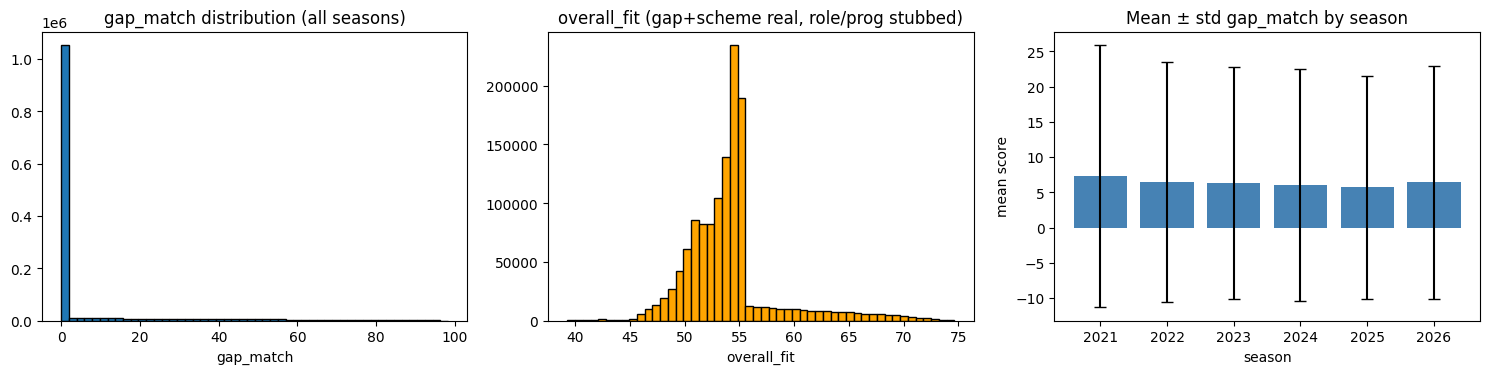


=== Per-season stats ===
        mean        std  min        max
season                                 
2021    7.31  18.639999  0.0  98.250000
2022    6.41  17.020000  0.0  98.070000
2023    6.33  16.510000  0.0  94.820000
2024    6.04  16.459999  0.0  98.040001
2025    5.71  15.800000  0.0  96.129997
2026    6.44  16.530001  0.0  98.239998

Top 5 schools by mean gap_match (2026):
school_id
102    23.650000
293    23.379999
36     13.060000
178    12.580000
9      12.430000
Name: gap_match, dtype: float32



Score spread comparison (std):
  gap_match std:  16.85
  scheme_fit std: 7.22


In [10]:
# Cell 8 — Validation
# Build DataFrame column-by-column via numpy to bypass pandas nested_data_to_arrays OOM.
# records tuple: (player_id, school_id, season, gap_match, overall_fit, breakdown_json, now_ts)
rec_df = pd.DataFrame({
    'player_id':   np.array([r[0] for r in records], dtype=np.int32),
    'school_id':   np.array([r[1] for r in records], dtype=np.int32),
    'season':      np.array([r[2] for r in records], dtype=np.int16),
    'gap_match':   np.array([r[3] for r in records], dtype=np.float32),
    'overall_fit': np.array([r[4] for r in records], dtype=np.float32),
})

print('=== Gap Match Score Distribution (all seasons) ===')
print(rec_df['gap_match'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rec_df['gap_match'], bins=50, edgecolor='black')
axes[0].set_title('gap_match distribution (all seasons)')
axes[0].set_xlabel('gap_match')

axes[1].hist(rec_df['overall_fit'], bins=50, edgecolor='black', color='orange')
axes[1].set_title('overall_fit (gap+scheme real, role/prog stubbed)')
axes[1].set_xlabel('overall_fit')

season_stats = rec_df.groupby('season')['gap_match'].agg(['mean', 'std'])
axes[2].bar(season_stats.index, season_stats['mean'], yerr=season_stats['std'],
            capsize=4, color='steelblue')
axes[2].set_title('Mean ± std gap_match by season')
axes[2].set_xlabel('season')
axes[2].set_ylabel('mean score')
plt.tight_layout()
plt.show()

print('\n=== Per-season stats ===')
print(rec_df.groupby('season')['gap_match'].agg(['mean', 'std', 'min', 'max']).round(2))

cur_df  = rec_df[rec_df['season'] == CURRENT_SEASON]
top_gap = cur_df.groupby('school_id')['gap_match'].mean().nlargest(5)
print(f'\nTop 5 schools by mean gap_match ({CURRENT_SEASON}):')
print(top_gap.round(2))

existing_df = pd.DataFrame({
    'scheme_fit': np.array([r[3] for r in existing_rows], dtype=np.float32),
})
print(f'\nScore spread comparison (std):')
print(f'  gap_match std:  {rec_df["gap_match"].std():.2f}')
print(f'  scheme_fit std: {existing_df["scheme_fit"].std():.2f}')

## 9. Write to DB

Upserts `gap_match`, recalculated `overall_fit`, and merged `breakdown.gap` JSON onto the existing Model 3 rows via `ON CONFLICT ... DO UPDATE`. `scheme_fit`, `role_fit`, `program_fit` and their weights are intentionally excluded from the `DO UPDATE SET` clause so Model 3's values are preserved.

In [11]:
# Cell 9 — DB write
# Stream records directly — no second dedup list.
# records can't have duplicates: df was drop_duplicates'd in Cell 1 and
# season_pairs sourced from unique-constrained (player_id, school_id, season) rows.

conn.rollback()

upserted = gm.upsert_gap_scores(engine, records)
print(f'Upserted {upserted:,} rows')

# Verify
with conn.cursor() as cur:
    cur.execute("""
        SELECT season,
               COUNT(*)                            AS n,
               ROUND(AVG(gap_match)::numeric, 2)   AS avg_gap,
               ROUND(AVG(scheme_fit)::numeric, 2)  AS avg_scheme,
               ROUND(AVG(overall_fit)::numeric, 2) AS avg_overall,
               COUNT(*) FILTER (WHERE gap_match IS NOT NULL) AS gap_populated
        FROM player_team_fit_scores
        GROUP BY season ORDER BY season
    """)
    rows = cur.fetchall()

print('\nDB verification:')
print(f'{"season":>8} {"n":>10} {"avg_gap":>10} {"avg_scheme":>12} {"avg_overall":>13} {"gap_populated":>14}')
for r in rows:
    print(f'{r[0]:>8} {r[1]:>10,} {str(r[2]):>10} {str(r[3]):>12} {str(r[4]):>13} {r[5]:>14,}')

conn.close()
print(f'\nGap Matching ({MODEL_VERSION}) complete ✓')
print('Next: wire gap_match into fit_scores.py API router')


Upserted 1,280,700 rows



DB verification:
  season          n    avg_gap   avg_scheme   avg_overall  gap_populated
    2021    211,950       7.31        92.55         54.23        211,950
    2022    225,150       6.41        92.83         54.13        225,150
    2023    226,050       6.33        92.38         53.98        226,050
    2024    226,600       6.04        92.91         54.08        226,600
    2025    227,050       5.71        92.91         54.01        227,050
    2026    226,250       5.77        93.06         54.07        226,250

Gap Matching (gap-cos-v2) complete ✓
Next: wire gap_match into fit_scores.py API router


## 10. MLflow Tracking

Logs params/metrics and a `GapMatchPyfunc` model artifact, mirroring `scheme_fit_scorer.ipynb` Section 7. The pyfunc artifact captures the core soft-weighted cosine metric (player stat vector vs. gap vector) for registry/drift monitoring — it does not reproduce full per-school state (benchmarks, roster composition), which lives only in this notebook's run.

In [12]:
# Cell 11 — MLflow Tracking
import mlflow
import mlflow.pyfunc
from portalpoint.modeling.mlflow_helpers import setup_mlflow, maybe_promote

EXPERIMENT    = 'gap-matching'
MODEL_NAME    = 'gap-matching-scorer'
ARTIFACT_PATH = 'gap_match_model'


class GapMatchPyfunc(mlflow.pyfunc.PythonModel):
    """Wraps the core soft-weighted gap-cosine metric for MLflow model registry.

    Input DataFrame columns: player_<feat> and gap_<feat> for each of the 8
    GAP_FEATURES (16 cols total). Output: list of dicts with 'gap_match' key
    (float 0-100). Captures the cosine metric only — position-weight blending
    and per-school gap-vector construction live in this notebook, not the
    registered artifact.
    """

    def predict(self, context, model_input):
        import numpy as np
        results = []
        for _, r in model_input.iterrows():
            p = np.array([r[f'player_{f}'] for f in GAP_FEATURES], dtype=np.float64)
            g = np.array([r[f'gap_{f}']    for f in GAP_FEATURES], dtype=np.float64)
            norm_p, norm_g = np.linalg.norm(p), np.linalg.norm(g)
            if norm_p == 0 or norm_g == 0:
                gm_score = 0.0
            else:
                gm_score = float(np.clip(np.dot(p, g) / (norm_p * norm_g) * 100, 0, 100))
            results.append({'gap_match': round(gm_score, 2)})
        return results


client = setup_mlflow(EXPERIMENT)

_mean_gap  = float(rec_df['gap_match'].mean())
_std_gap   = float(rec_df['gap_match'].std())
_n_records = len(records)
_n_players = int(df['player_id'].nunique())
_n_schools = int(df['school_id'].nunique())
_he_pct    = float(100 * he_cov / len(df))

with mlflow.start_run(run_name=f'gap-match-s{CURRENT_SEASON}') as run:
    mlflow.log_params({
        'seasons':         ','.join(str(s) for s in SEASONS_IN_DATA),
        'min_games':       MIN_GAMES,
        'feature_dims':    len(GAP_FEATURES),
        'features':        ','.join(GAP_FEATURES),
        'sim_method':      'soft-weighted-cosine',
        'model_version':   MODEL_VERSION,
        'he_coverage_pct': round(_he_pct, 1),
    })
    mlflow.log_metrics({
        'mean_gap_match':    _mean_gap,
        'std_gap_match':     _std_gap,
        'p10_gap_match':     float(np.percentile(rec_df['gap_match'], 10)),
        'p90_gap_match':     float(np.percentile(rec_df['gap_match'], 90)),
        'n_records_written': float(_n_records),
        'n_players':         float(_n_players),
        'n_schools':         float(_n_schools),
    })

    mlflow.pyfunc.log_model(
        artifact_path=ARTIFACT_PATH,
        python_model=GapMatchPyfunc(),
    )

    run_id = run.info.run_id

result = maybe_promote(
    client, MODEL_NAME, run_id, ARTIFACT_PATH,
    metric_name='std_gap_match',
    new_value=_std_gap,
    higher_is_better=True,
)
print(f'Run ID  : {run_id}')
print(f'Registry: {result}')


c:\Users\shant\Desktop\MIDS\MIDS210-Capstone\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


2026/06/21 13:47:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/21 13:47:48 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/06/21 13:48:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'gap-matching-scorer' already exists. Creating a new version of this model...


2026/06/21 13:50:06 WARNING mlflow.tracking._model_registry.fluent: Run with id 55b426ac55834c16a98027e9918c74e8 has no artifacts at artifact path 'gap_match_model', registering model based on models:/m-3635c20be39c4ad8a6433d8f5123f2fa instead


Created version '4' of model 'gap-matching-scorer'.


Run ID  : 55b426ac55834c16a98027e9918c74e8
Registry: staging — gap-matching-scorer v4 → Staging (Δ=-0.1%)
